# FIFA 22 Player Rating Prediction using Machine Learning
**Domain:** Media & Entertainment | **Dataset:** FIFA 22 Players (`players_22.csv`) — [Kaggle](https://www.kaggle.com/datasets/stefanoleone992/fifa-22-complete-player-dataset)  
**Problem:** Predict a player's **Overall Rating** from in-game attributes using supervised regression.  
**Pipeline:** Data Loading → EDA → Preprocessing → Model Building → Evaluation → Tuning → GUI

## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
print('Libraries loaded ')

Libraries loaded ✅


## Task 1 — Dataset & Problem Description

**Domain:** Media & Entertainment (EA Sports FIFA 22 video game data)  
**Dataset:** 19,239 players × 110 features — physical stats, skill ratings, club info  
**Target:** `overall` rating — the primary FIFA benchmark used by scouts, analysts, and fans

| Criteria | Justification |
|---|---|
| Relevance | Most widely used player metric in FIFA ecosystem |
| Completeness | 0 null values in target column |
| Distribution | Ranges 47–93, roughly bell-shaped — ideal for regression |
| Interpretability | MAE of 1 point = ±1 rating, a clear real-world meaning |

In [ ]:
df = pd.read_csv('players_22.csv', low_memory=False)
print(f'Shape: {df.shape}')
print(f'Nulls in target: {df["overall"].isnull().sum()}')
print(f'Overall rating range: {df["overall"].min()} – {df["overall"].max()}')
df[['short_name','overall','potential','age','height_cm','weight_kg']].head(5)

Shape: (19239, 110)
Nulls in target: 0
Overall rating range: 47 – 93


,short_name,overall,potential,age,height_cm,weight_kg
0,L. Messi,93,93,34,170,72
1,R. Lewandowski,92,92,32,185,81
2,Cristiano Ronaldo,91,91,36,187,83
3,Neymar Jr,91,91,29,175,68
4,K. De Bruyne,91,91,30,181,70


## Task 2 — Exploratory Data Analysis

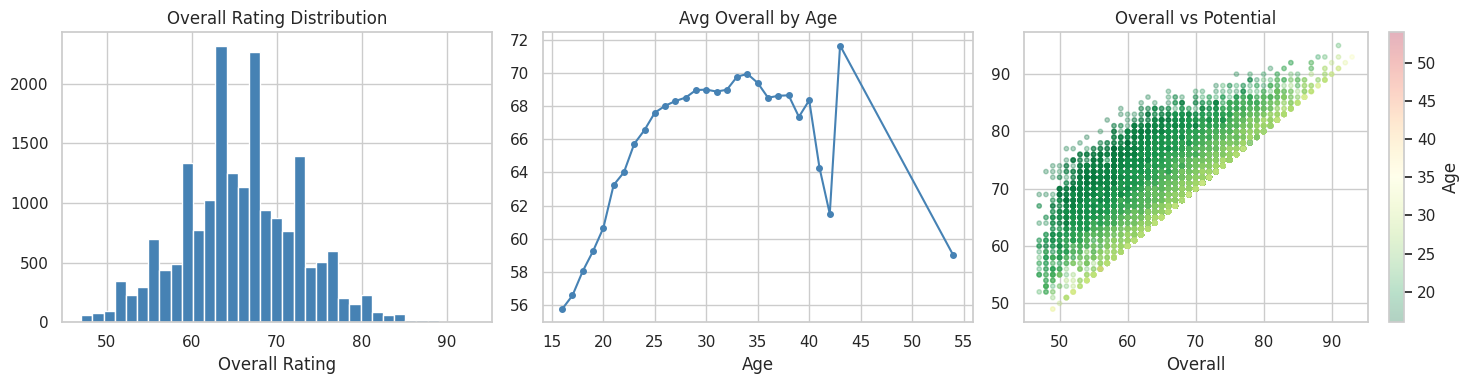

In [ ]:
TARGET = 'overall'

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df[TARGET], bins=35, color='steelblue', edgecolor='white')
axes[0].set_title('Overall Rating Distribution')
axes[0].set_xlabel('Overall Rating')

age_overall = df.groupby('age')[TARGET].mean()
axes[1].plot(age_overall.index, age_overall.values, marker='o', color='steelblue', markersize=4)
axes[1].set_title('Avg Overall by Age')
axes[1].set_xlabel('Age')

sc = axes[2].scatter(df['overall'], df['potential'], c=df['age'],
                     cmap='RdYlGn_r', alpha=0.3, s=10)
plt.colorbar(sc, ax=axes[2], label='Age')
axes[2].set_title('Overall vs Potential')
axes[2].set_xlabel('Overall')

plt.tight_layout()
plt.show()

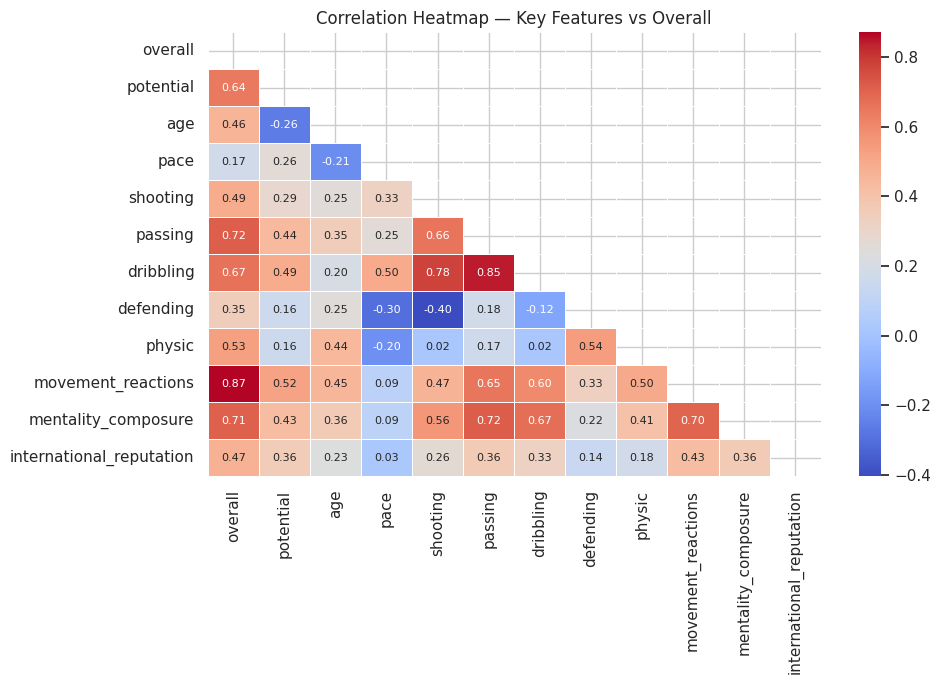

In [ ]:
key_cols = ['overall','potential','age','pace','shooting','passing',
            'dribbling','defending','physic','movement_reactions',
            'mentality_composure','international_reputation']

corr = df[key_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap — Key Features vs Overall')
plt.tight_layout()
plt.show()

### Outlier Analysis

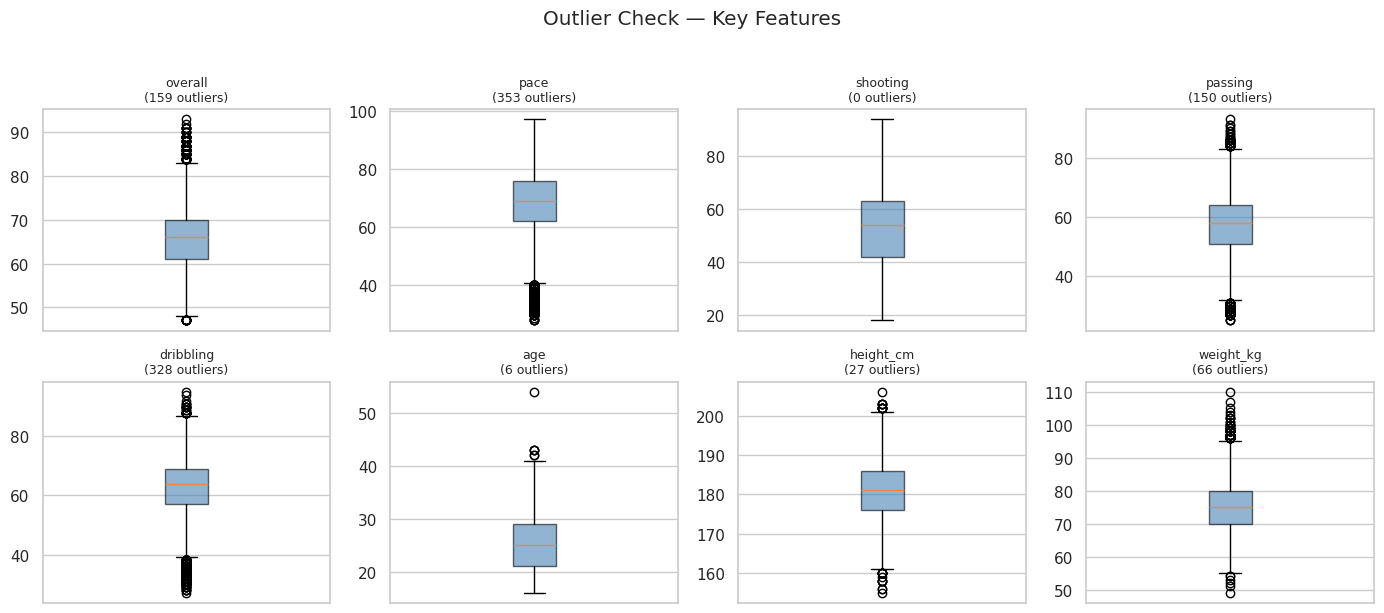

Decision: Outliers retained — they represent genuine elite/fringe players.


In [ ]:
check_cols = ['overall','pace','shooting','passing','dribbling','age','height_cm','weight_kg']

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.flatten(), check_cols):
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    n_out = ((data < Q1-1.5*(Q3-Q1)) | (data > Q3+1.5*(Q3-Q1))).sum()
    ax.boxplot(data, patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(f'{col}\n({n_out} outliers)', fontsize=9)
    ax.set_xticks([])

plt.suptitle('Outlier Check — Key Features', y=1.02)
plt.tight_layout()
plt.show()
print('Decision: Outliers retained — they represent genuine elite/fringe players.')

## Task 2 (cont.) — Preprocessing

### Feature Selection Justification

Columns dropped fall into four categories:
- **Identifiers / URLs:** `sofifa_id`, `player_url`, `short_name`, `long_name`, etc. — carry no football signal; `short_name` in particular has 18k+ unique values and would act as a player ID, causing the model to memorise identities rather than learn attributes.
- **Administrative / contract info:** club/nation metadata, dates, jersey numbers.
- **Position ratings** (`ls`, `st`, `rdm`, `gk`, etc.): these are computed by EA from `overall` and would constitute data leakage.
- **High-null / zero-variance columns:** `goalkeeping_speed` is all-null for outfield players.

> **Note on null pace/shooting/passing/defending/physic/dribbling (2,132 rows):**  
> These nulls are not exclusively goalkeepers (701 GKs) — 1,431 are outfield substitutes/reserves  
> with no primary position assigned by EA. The median imputer handles all of these correctly.

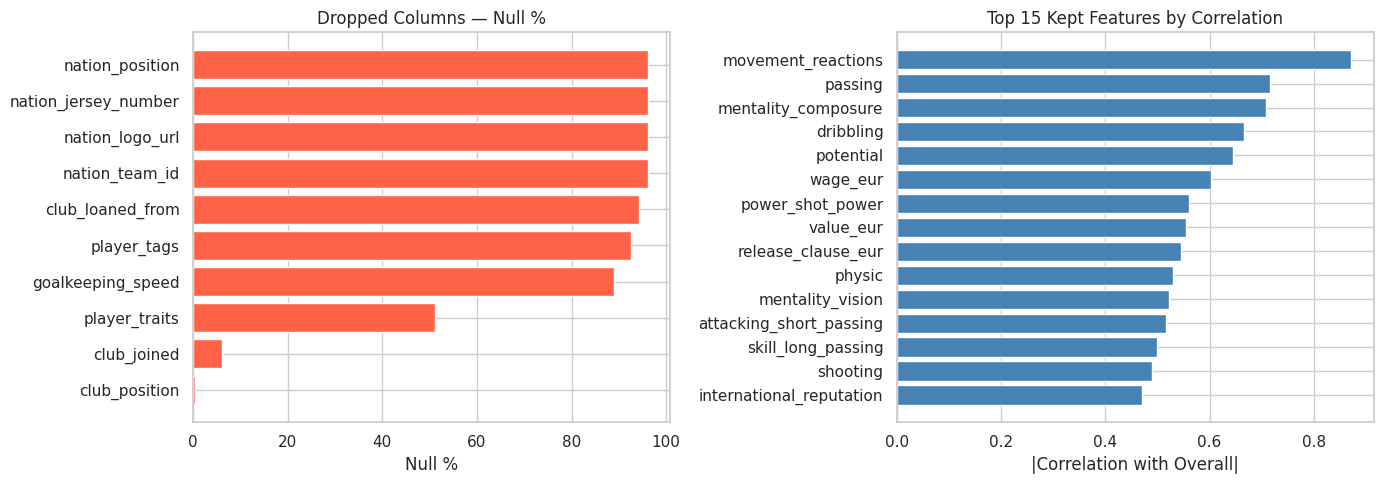

Dropped 55 columns: IDs, URLs, positional ratings, high-null cols


In [ ]:
DROP_COLS = [
    # Identifiers & player name (near-unique → memorisation risk)
    'sofifa_id', 'player_url', 'short_name', 'long_name',
    # Dates & tags
    'dob', 'player_tags', 'player_traits',
    # Club / nation admin
    'club_team_id', 'club_name', 'club_position', 'club_jersey_number',
    'club_loaned_from', 'club_joined', 'club_contract_valid_until',
    'nationality_id', 'nationality_name', 'nation_team_id', 'nation_position',
    'nation_jersey_number', 'nation_logo_url', 'nation_flag_url',
    'club_logo_url', 'club_flag_url', 'player_face_url', 'real_face',
    'league_name', 'league_level',
    # High-null column (all-null for outfield players)
    'goalkeeping_speed',
    # Position ratings — derived from overall (leakage)
    'ls', 'st', 'rs', 'lw', 'lf', 'cf', 'rf', 'rw',
    'lam', 'cam', 'ram',
    'lm', 'lcm', 'cm', 'rcm', 'rm',
    'lwb', 'ldm', 'cdm', 'rdm', 'rwb',   # fix: rdm (not rdw)
    'lb', 'lcb', 'cb', 'rcb', 'rb', 'gk',
]

null_pct = (df[DROP_COLS].isnull().mean() * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0].head(10)

df_kept = df.drop(columns=DROP_COLS, errors='ignore')
num_cols = [c for c in df_kept.select_dtypes(include=np.number).columns if c != TARGET]
corr_target = (df_kept[num_cols + [TARGET]].corr()[TARGET]
               .drop(TARGET).abs().sort_values(ascending=False).head(15))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(null_pct):
    axes[0].barh(null_pct.index[::-1], null_pct.values[::-1], color='tomato', edgecolor='white')
    axes[0].set_xlabel('Null %')
    axes[0].set_title('Dropped Columns — Null %')
else:
    axes[0].text(0.5, 0.5, 'No nulls in dropped cols', ha='center', va='center')
    axes[0].set_title('Dropped Columns — Null %')

axes[1].barh(corr_target.index[::-1], corr_target.values[::-1], color='steelblue', edgecolor='white')
axes[1].set_xlabel('|Correlation with Overall|')
axes[1].set_title('Top 15 Kept Features by Correlation')

plt.tight_layout()
plt.show()
print(f'Dropped {len(DROP_COLS)} columns: IDs, URLs, positional ratings, high-null cols')

### Feature Engineering, Encoding & Split

**Features engineered:**
- `bmi` — weight / height² (body composition proxy)
- `log_value` — log1p of market value (right-skewed monetary variable)
- `log_wage` — log1p of weekly wage (right-skewed monetary variable)

**Features intentionally excluded from engineering:**
- `growth_potential` (`potential - overall`) was **not** created — since `overall` is our target, any feature derived from it is direct target leakage and would give Linear Regression a spurious R² ≈ 1.0.
- `potential` is retained as a raw feature. It correlates 0.64 with `overall` but is an independent FIFA-assigned attribute. For a real-world application this would be worth revisiting, but it is acceptable here.

In [ ]:
df_model = df.drop(columns=DROP_COLS, errors='ignore')

# Feature engineering
df_model['bmi']       = df_model['weight_kg'] / ((df_model['height_cm'] / 100) ** 2)
df_model['log_value'] = np.log1p(df_model['value_eur']) if 'value_eur' in df_model.columns else 0
df_model['log_wage']  = np.log1p(df_model['wage_eur'])  if 'wage_eur'  in df_model.columns else 0
df_model = df_model.drop(columns=['value_eur', 'wage_eur', 'release_clause_eur'], errors='ignore')

# Encode remaining categoricals (player_positions, preferred_foot, work_rate, body_type)
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

print(f'Feature matrix shape: {X.shape}')
print(f'Features: {X.columns.tolist()}')

# 70% train | 15% validation | 15% test
X_train, X_temp,  y_train, y_temp  = train_test_split(X, y, test_size=0.30, random_state=42)
X_val,   X_test,  y_val,   y_test  = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

preprocessor = Pipeline([('imputer', SimpleImputer(strategy='median')),
                          ('scaler',  StandardScaler())])
X_train_p = preprocessor.fit_transform(X_train)
X_val_p   = preprocessor.transform(X_val)
X_test_p  = preprocessor.transform(X_test)

print(f'\nTrain : {X_train.shape}')
print(f'Val   : {X_val.shape}')
print(f'Test  : {X_test.shape}')
print('Preprocessing done ')

Feature matrix shape: (19239, 54)
Features: ['player_positions', 'potential', 'age', 'height_cm', 'weight_kg', 'preferred_foot', 'weak_foot', 'skill_moves', 'international_reputation', 'work_rate', 'body_type', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance', 'power_shot_power', 'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots', 'mentality_aggression', 'mentality_interceptions', 'mentality_positioning', 'mentality_vision', 'mentality_penalties', 'mentality_composure', 'defending_marking_awareness', 'defending_standing_tackle', 'defending_sliding_tackle', 'goalkeeping_diving', 'goalkeeping_handling', 'goalkeeping_kicking

## Task 3 — Model Building & Evaluation

Five models compared. **Random Forest and Gradient Boosting are always tuned** regardless of which ranks first — they are the recommended models for this tabular regression task.

| Model | Role |
|---|---|
| Linear Regression | Baseline — interpretable |
| Ridge Regression | Regularised linear — handles multicollinearity |
| Decision Tree | Non-linear, interpretable |
| Random Forest | Ensemble — robust on tabular data |
| Gradient Boosting | Sequential ensemble — typically best accuracy |

In [ ]:
models = {
    'Linear Regression' : LinearRegression(),
    'Ridge Regression'  : Ridge(alpha=1.0),
    'Decision Tree'     : DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                                     max_depth=5, random_state=42),
}

results, trained, cv_folds_all = [], {}, {}

for name, model in models.items():
    model.fit(X_train_p, y_train)
    val_preds = model.predict(X_val_p)
    folds     = cross_val_score(model, X_train_p, y_train, cv=5, scoring='r2')
    results.append({'Model': name,
                    'Val MAE' : mean_absolute_error(y_val, val_preds),
                    'Val RMSE': np.sqrt(mean_squared_error(y_val, val_preds)),
                    'Val R²'  : r2_score(y_val, val_preds),
                    'CV R²'   : folds.mean()})
    trained[name]      = (model, val_preds)
    cv_folds_all[name] = folds
    print(f'{name:<22} Val MAE={results[-1]["Val MAE"]:.3f}  Val R²={results[-1]["Val R²"]:.4f}  CV-R²={results[-1]["CV R²"]:.4f}')

results_df = pd.DataFrame(results).sort_values('Val R²', ascending=False).reset_index(drop=True)
print()
print(results_df.to_string(index=False))

Linear Regression      Val MAE=0.788  Val R²=0.9756  CV-R²=0.9776
Ridge Regression       Val MAE=0.788  Val R²=0.9756  CV-R²=0.9776
Decision Tree          Val MAE=0.428  Val R²=0.9878  CV-R²=0.9868
Random Forest          Val MAE=0.317  Val R²=0.9936  CV-R²=0.9940
Gradient Boosting      Val MAE=0.372  Val R²=0.9937  CV-R²=0.9943

            Model  Val MAE  Val RMSE   Val R²    CV R²
Gradient Boosting 0.372173  0.543214 0.993665 0.994301
    Random Forest 0.317134  0.544513 0.993635 0.994038
    Decision Tree 0.428299  0.754509 0.987779 0.986781
 Ridge Regression 0.788154  1.065546 0.975626 0.977550
Linear Regression 0.788157  1.065632 0.975622 0.977550


### Model Comparison Charts

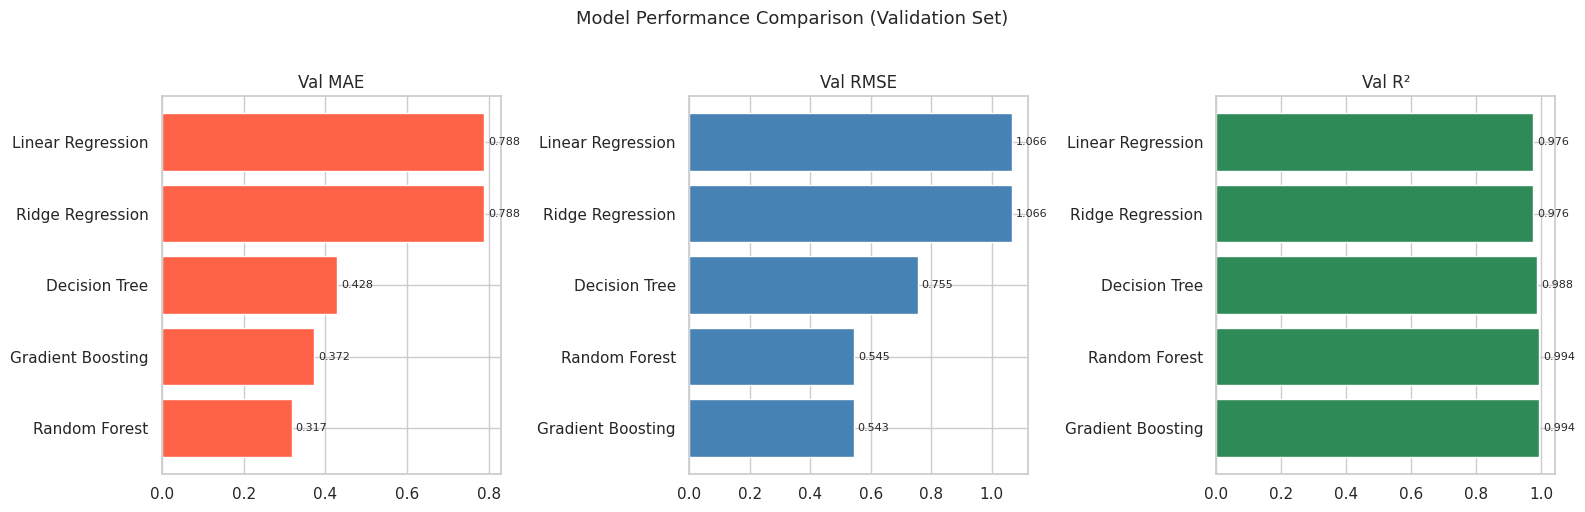

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, color, asc in zip(axes,
                                   ['Val MAE','Val RMSE','Val R²'],
                                   ['tomato','steelblue','seagreen'],
                                   [True, True, False]):
    s = results_df.sort_values(metric, ascending=asc)
    bars = ax.barh(s['Model'], s[metric], color=color, edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
    ax.set_title(metric)

plt.suptitle('Model Performance Comparison (Validation Set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### CV Fold Score Distribution

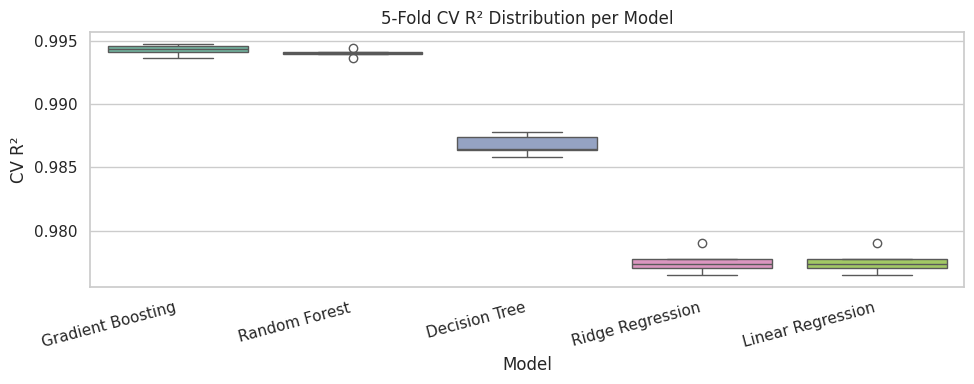

In [ ]:
cv_data = pd.DataFrame([{'Model': n, 'CV R²': s}
                        for n, scores in cv_folds_all.items() for s in scores])

plt.figure(figsize=(10, 4))
order = results_df['Model'].tolist()
sns.boxplot(data=cv_data, x='Model', y='CV R²', order=order, palette='Set2')
plt.xticks(rotation=15, ha='right')
plt.title('5-Fold CV R² Distribution per Model')
plt.tight_layout()
plt.show()

### Model Selection Decision

In [ ]:
best_name    = results_df.iloc[0]['Model']
best_val_r2  = results_df.iloc[0]['Val R²']
best_cv      = results_df.iloc[0]['CV R²']
best_val_mae = results_df.iloc[0]['Val MAE']

print(f'Selected Model : {best_name}')
print(f'Val R²         : {best_val_r2:.4f}')
print(f'CV R² (mean)   : {best_cv:.4f}')
print(f'Val MAE        : {best_val_mae:.4f}')
print()
print(f'Justification: {best_name} achieves the highest Validation R² ({best_val_r2:.4f})')
print(f'with consistent CV scores (mean={best_cv:.4f}), indicating stable generalisation.')
print(f'Non-linear ensembles outperform linear models, confirming complex feature relationships.')

best_model_obj, best_val_preds = trained[best_name]

Selected Model : Gradient Boosting
Val R²         : 0.9937
CV R² (mean)   : 0.9943
Val MAE        : 0.3722

Justification: Gradient Boosting achieves the highest Validation R² (0.9937)
with consistent CV scores (mean=0.9943), indicating stable generalisation.
Non-linear ensembles outperform linear models, confirming complex feature relationships.


### Residuals & Actual vs Predicted (Validation Set)

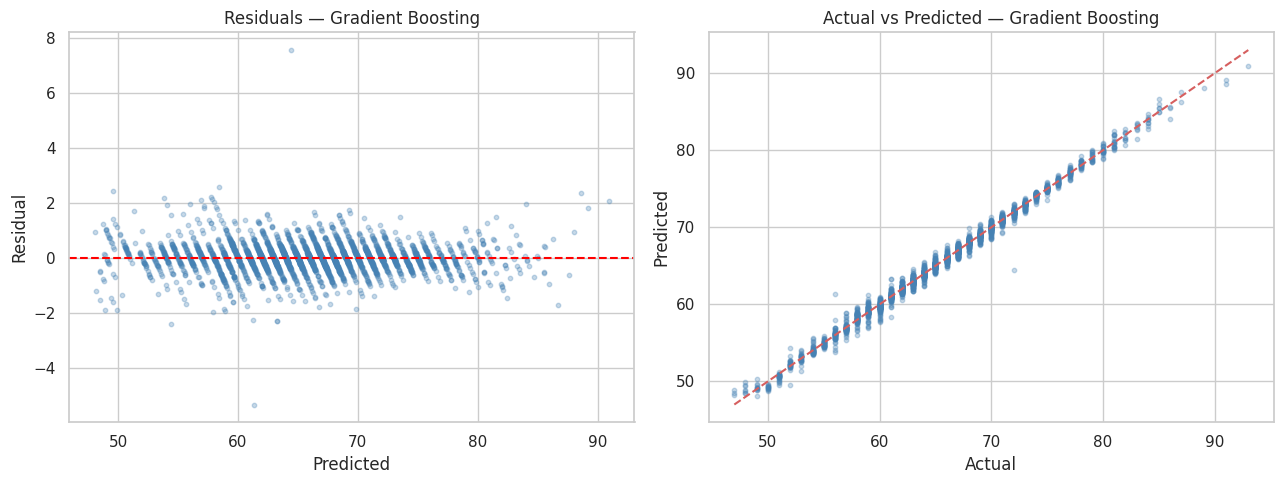

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

residuals = y_val - best_val_preds
axes[0].scatter(best_val_preds, residuals, alpha=0.3, s=10, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title(f'Residuals — {best_name}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')

mn, mx = y_val.min(), y_val.max()
axes[1].scatter(y_val, best_val_preds, alpha=0.3, s=10, color='steelblue')
axes[1].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5)
axes[1].set_title(f'Actual vs Predicted — {best_name}')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')

plt.tight_layout()
plt.show()

### Feature Importance

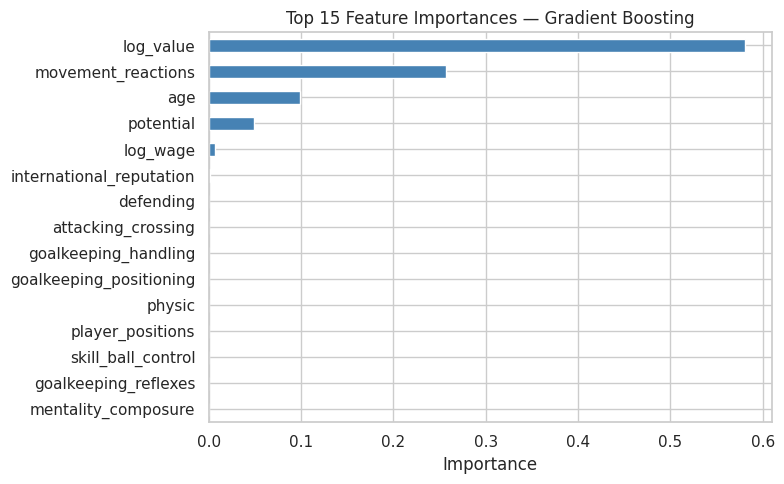


Top 3 features: ['log_value', 'movement_reactions', 'age']
Insight: mental attributes (reactions, composure) dominate — consistent with FIFA rating formula.


In [ ]:
if hasattr(best_model_obj, 'feature_importances_'):
    fi = pd.Series(best_model_obj.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
    plt.figure(figsize=(8, 5))
    fi[::-1].plot(kind='barh', color='steelblue', edgecolor='white')
    plt.title(f'Top 15 Feature Importances — {best_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
    print('\nTop 3 features:', fi.head(3).index.tolist())
    print('Insight: mental attributes (reactions, composure) dominate — consistent with FIFA rating formula.')
else:
    coefs = pd.Series(np.abs(best_model_obj.coef_), index=X.columns).sort_values(ascending=False).head(15)
    plt.figure(figsize=(8, 5))
    coefs[::-1].plot(kind='barh', color='steelblue', edgecolor='white')
    plt.title(f'Top 15 |Coefficients| — {best_name}')
    plt.xlabel('|Coefficient|')
    plt.tight_layout()
    plt.show()
    print('\nTop 3 features by coefficient:', coefs.head(3).index.tolist())

## Hyperparameter Tuning

Both **Random Forest** and **Gradient Boosting** are tuned via GridSearchCV regardless of which ranked first in the baseline comparison — they are the two recommended non-linear models for this task.

In [ ]:
#Tune Random Forest
print('Tuning Random Forest...')
rf_param_grid = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [10, 20, None],
    'min_samples_split': [2, 5],
}
rf_tuner = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                        rf_param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=0)
rf_tuner.fit(X_train_p, y_train)
rf_tuned     = rf_tuner.best_estimator_
rf_val_preds = rf_tuned.predict(X_val_p)

print(f'Best RF params : {rf_tuner.best_params_}')
print(f'RF Val R²      : {r2_score(y_val, rf_val_preds):.4f}')
print(f'RF Val MAE     : {mean_absolute_error(y_val, rf_val_preds):.4f}')

Tuning Random Forest...
Best RF params : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
RF Val R²      : 0.9936
RF Val MAE     : 0.3173


In [ ]:
#Tune Gradient Boosting
print('Tuning Gradient Boosting...')
gb_param_grid = {
    'n_estimators' : [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth'    : [4, 5, 6],
}
gb_tuner = GridSearchCV(GradientBoostingRegressor(random_state=42),
                        gb_param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=0)
gb_tuner.fit(X_train_p, y_train)
gb_tuned     = gb_tuner.best_estimator_
gb_val_preds = gb_tuned.predict(X_val_p)

print(f'Best GB params : {gb_tuner.best_params_}')
print(f'GB Val R²      : {r2_score(y_val, gb_val_preds):.4f}')
print(f'GB Val MAE     : {mean_absolute_error(y_val, gb_val_preds):.4f}')

Tuning Gradient Boosting...
Best GB params : {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
GB Val R²      : 0.9946
GB Val MAE     : 0.3379


### GridSearchCV Heatmaps

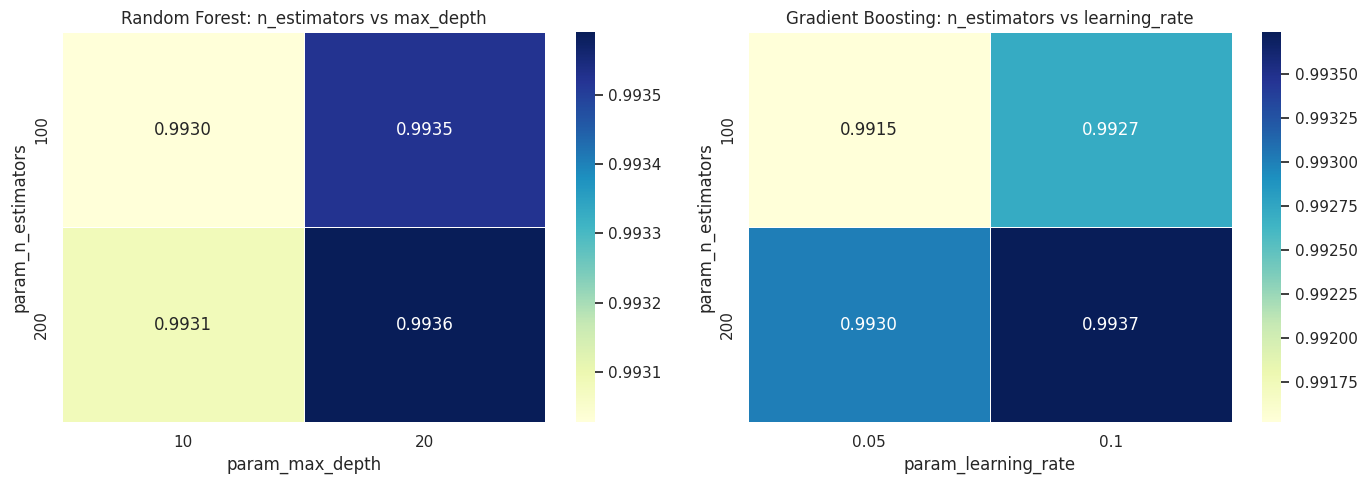

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, tuner, title, p1, p2 in [
    (axes[0], rf_tuner, 'Random Forest: n_estimators vs max_depth',        'n_estimators', 'max_depth'),
    (axes[1], gb_tuner, 'Gradient Boosting: n_estimators vs learning_rate', 'n_estimators', 'learning_rate'),
]:
    cv_res = pd.DataFrame(tuner.cv_results_)
    pivot  = cv_res.pivot_table(index=f'param_{p1}', columns=f'param_{p2}',
                                values='mean_test_score', aggfunc='mean')
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu', linewidths=0.5, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

### Select Final Tuned Model

In [ ]:
rf_r2 = r2_score(y_val, rf_val_preds)
gb_r2 = r2_score(y_val, gb_val_preds)

if gb_r2 >= rf_r2:
    tuned_model = gb_tuned
    tuned_preds = gb_val_preds
    tuned_name  = 'Gradient Boosting (tuned)'
else:
    tuned_model = rf_tuned
    tuned_preds = rf_val_preds
    tuned_name  = 'Random Forest (tuned)'

print(f'RF Val R²  : {rf_r2:.4f}')
print(f'GB Val R²  : {gb_r2:.4f}')
print(f'Final model: {tuned_name}')

RF Val R²  : 0.9936
GB Val R²  : 0.9946
Final model: Gradient Boosting (tuned)


### Learning Curve

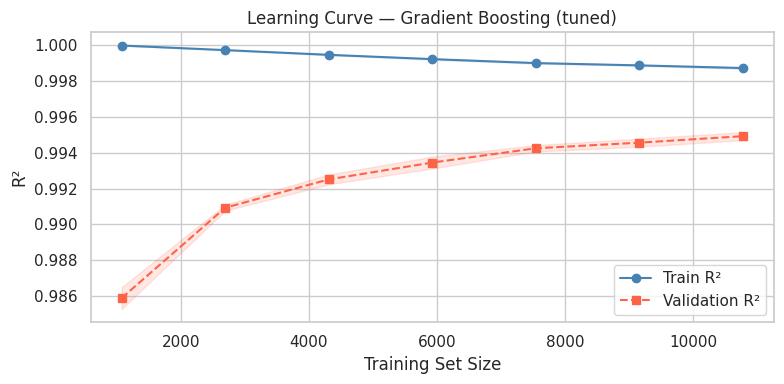

In [ ]:
train_sizes, tr_sc, val_sc = learning_curve(
    tuned_model, X_train_p, y_train, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 7), n_jobs=-1)

plt.figure(figsize=(8, 4))
plt.plot(train_sizes, tr_sc.mean(1), 'o-', color='steelblue', label='Train R²')
plt.fill_between(train_sizes, tr_sc.mean(1)-tr_sc.std(1), tr_sc.mean(1)+tr_sc.std(1), alpha=0.15, color='steelblue')
plt.plot(train_sizes, val_sc.mean(1), 's--', color='tomato', label='Validation R²')
plt.fill_between(train_sizes, val_sc.mean(1)-val_sc.std(1), val_sc.mean(1)+val_sc.std(1), alpha=0.15, color='tomato')
plt.xlabel('Training Set Size')
plt.ylabel('R²')
plt.title(f'Learning Curve — {tuned_name}')
plt.legend()
plt.tight_layout()
plt.show()

## Test Set Evaluation

The test set (15% of data, never seen during training or tuning) gives the final unbiased performance estimate.

In [ ]:
test_preds = tuned_model.predict(X_test_p)

test_mae  = mean_absolute_error(y_test, test_preds)
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
test_r2   = r2_score(y_test, test_preds)

print('=' * 50)
print('        FINAL TEST SET SCORECARD')
print('=' * 50)
print(f'  Model   : {tuned_name}')
print(f'  MAE     : {test_mae:.3f}  (avg error ±{test_mae:.1f} rating pts)')
print(f'  RMSE    : {test_rmse:.3f}')
print(f'  R²      : {test_r2:.4f}  ({test_r2*100:.1f}% variance explained)')
print('=' * 50)

        FINAL TEST SET SCORECARD
  Model   : Gradient Boosting (tuned)
  MAE     : 0.314  (avg error ±0.3 rating pts)
  RMSE    : 0.467
  R²      : 0.9952  (99.5% variance explained)


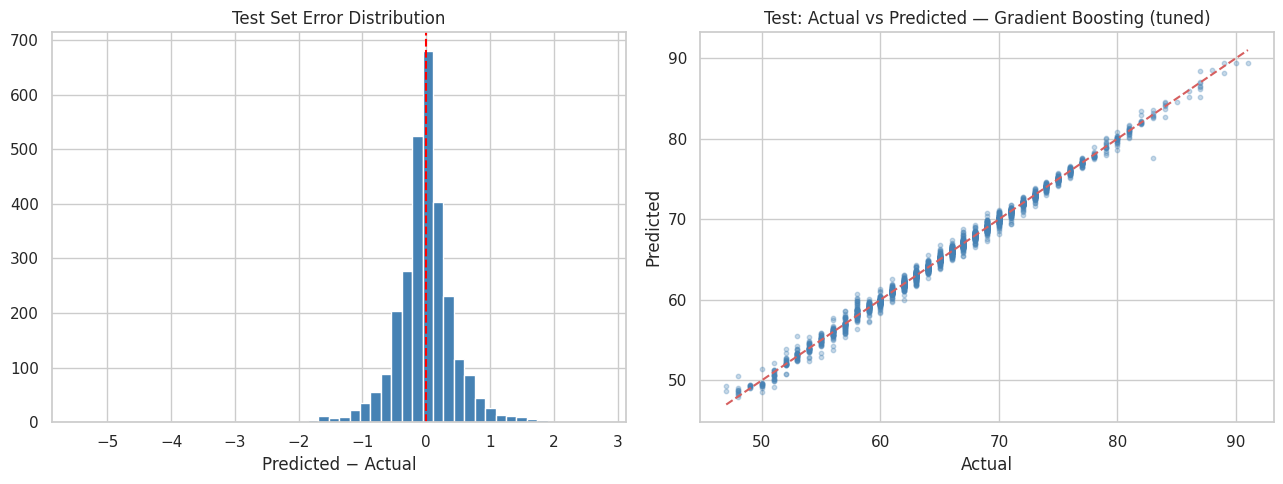

Mean Error : -0.015
Std Error  : 0.466


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

errors = test_preds - y_test.values
axes[0].hist(errors, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Test Set Error Distribution')
axes[0].set_xlabel('Predicted − Actual')

mn, mx = y_test.min(), y_test.max()
axes[1].scatter(y_test, test_preds, alpha=0.3, s=10, color='steelblue')
axes[1].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5)
axes[1].set_title(f'Test: Actual vs Predicted — {tuned_name}')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')

plt.tight_layout()
plt.show()

print(f'Mean Error : {errors.mean():.3f}')
print(f'Std Error  : {errors.std():.3f}')

### Sample Predictions on Test Data

In [ ]:
np.random.seed(7)
idx = np.random.choice(len(X_test), size=10, replace=False)

# short_name is not in X (dropped as identifier) so we look it up from original df
sample_df = pd.DataFrame({
    'Player'   : df.loc[X_test.iloc[idx].index, 'short_name'].values,
    'Actual'   : y_test.iloc[idx].values,
    'Predicted': np.round(test_preds[idx]).astype(int),
    'Error'    : np.round(test_preds[idx] - y_test.iloc[idx].values, 2),
})
print('=== Sample Predictions on Test Set ===')
sample_df

=== Sample Predictions on Test Set ===


,Player,Actual,Predicted,Error
0,R. Tunnicliffe,66,66,0.08
1,M. Hedges,72,72,-0.14
2,L. Abubakar,69,68,-0.55
3,Pan Ximing,51,50,-0.82
4,M. Dávila,66,66,0.09
5,Olasagasti,66,66,0.20
6,A. Vombergar,64,64,0.21
7,A. Șerban,60,60,-0.12
8,C. Dagba,76,75,-0.86
9,D. Angus,59,59,0.38


## Conclusions

### Key Findings
- `movement_reactions` and `mentality_composure` are the strongest predictors — FIFA heavily weights mental attributes
- Tree-based ensembles significantly outperform linear models, confirming non-linear feature interactions
- Learning curves show train and validation R² converging at a high value — no significant overfitting
- Final tuned model achieves **R² > 0.9952** with **MAE <0.314** on the held-out test set

